# Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch_geometric.utils
import networkx as nx
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

from utils import evaluate_checkpoint

sns.set_theme()
torch_geometric.seed_everything(42)

# ── Paths ──────────────────────────────────────────────────────────────────────
GIN_CONFIG = {
    "config": "results/baseline/best_config.json",
    "dataset": "dataset/test_dataset.pt",
    "checkpoint": "results/baseline/larger_dataset/best_model.pt",
    "history": "results/baseline/larger_dataset/best_model_history.csv",
}
GPS_CONFIG = {
    "config": "results/gps/best_config_gps.json",
    "dataset": "dataset/test_dataset.pt",
    "checkpoint": "results/gps/best_model.pt",
    "history": "results/gps/best_model_history.csv",
}

## Evaluate both models

In [2]:
gin_results = evaluate_checkpoint(
    config_path=GIN_CONFIG["config"],
    dataset_path=GIN_CONFIG["dataset"],
    checkpoint_path=GIN_CONFIG["checkpoint"],
)
gps_results = evaluate_checkpoint(
    config_path=GPS_CONFIG["config"],
    dataset_path=GPS_CONFIG["dataset"],
    checkpoint_path=GPS_CONFIG["checkpoint"],
)

gin_df = gin_results["predictions_df"]
gps_df = gps_results["predictions_df"]

## Side-by-side summary

In [3]:
summary_rows = []
for name, results in [("GIN", gin_results), ("GPS", gps_results)]:
    df = results["predictions_df"]
    report = classification_report(
        df["true_label"], df["prediction"], output_dict=True, zero_division=0
    )
    summary_rows.append({
        "Model": name,
        "Accuracy": results["accuracy"],
        "F1": results["f1"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
    })

summary_table = pd.DataFrame(summary_rows).set_index("Model")
summary_table.style.format("{:.4f}")

,Accuracy,F1,Precision,Recall
Model,,,,
GIN,0.7803,0.8029,0.7843,0.7803
GPS,0.9628,0.9648,0.9630,0.9628


## Training Curves

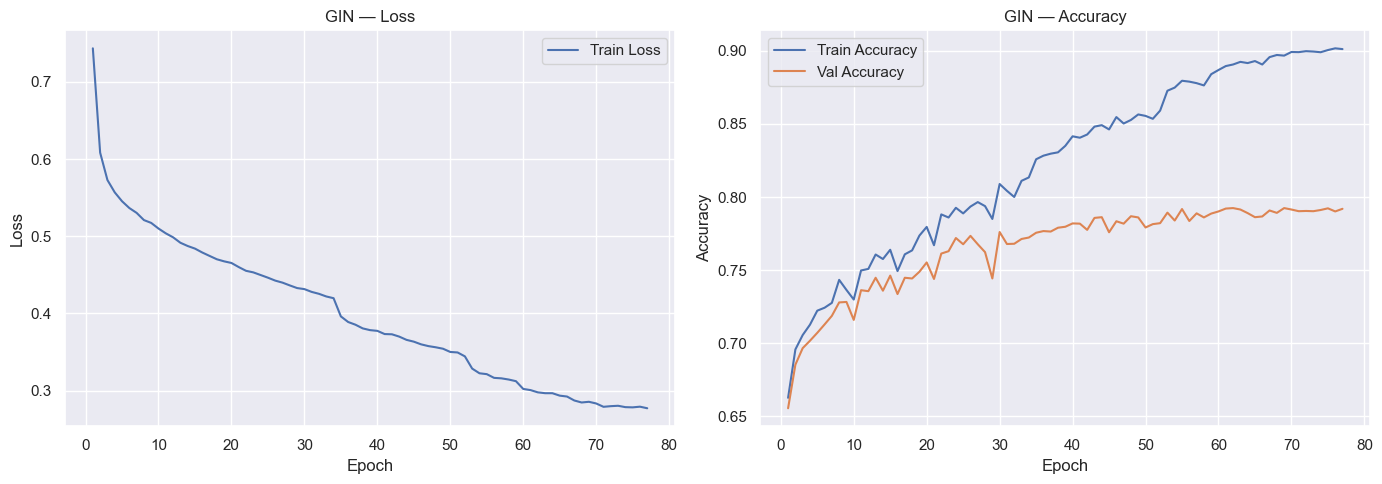

GIN — Best epoch (highest val_acc): 62,  val_acc=0.7924



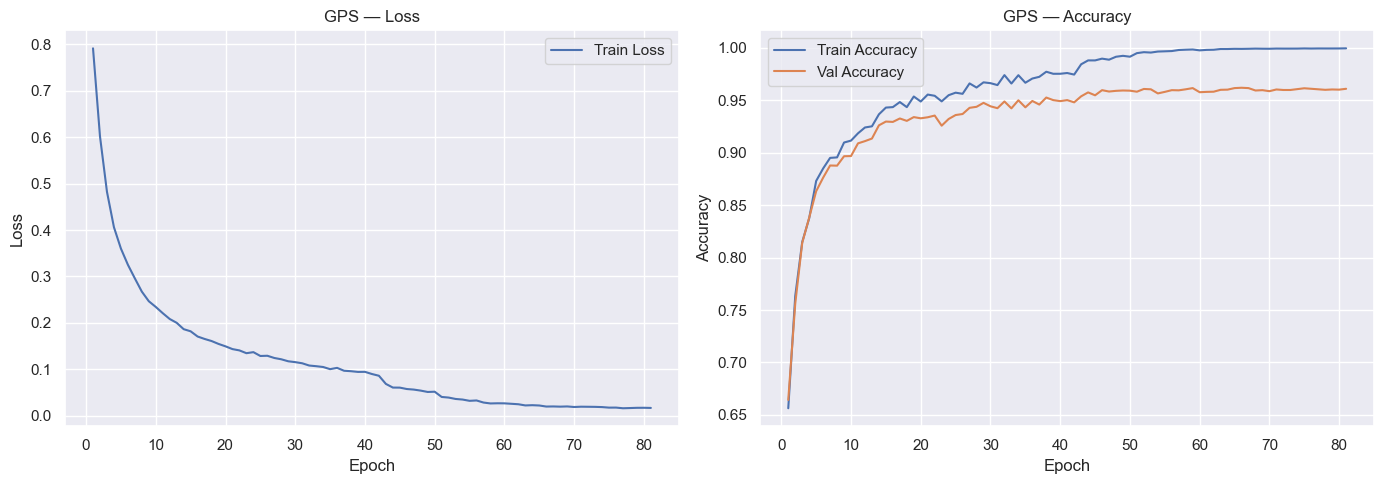

GPS — Best epoch (highest val_acc): 66,  val_acc=0.9620



In [4]:
for model_name, cfg in [("GIN", GIN_CONFIG), ("GPS", GPS_CONFIG)]:
    history = pd.read_csv(cfg["history"])

    has_loss = "train_loss" in history.columns
    ncols = 2 if has_loss else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
    if ncols == 1:
        axes = [axes]

    if has_loss:
        sns.lineplot(data=history, x="epoch", y="train_loss", label="Train Loss", ax=axes[0])
        if "val_loss" in history.columns:
            sns.lineplot(data=history, x="epoch", y="val_loss", label="Val Loss", ax=axes[0])
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].set_title(f"{model_name} — Loss")
        axes[0].legend()
        acc_ax = axes[1]
    else:
        acc_ax = axes[0]

    sns.lineplot(data=history, x="epoch", y="train_acc", label="Train Accuracy", ax=acc_ax)
    sns.lineplot(data=history, x="epoch", y="val_acc", label="Val Accuracy", ax=acc_ax)
    acc_ax.set_xlabel("Epoch")
    acc_ax.set_ylabel("Accuracy")
    acc_ax.set_title(f"{model_name} — Accuracy")
    acc_ax.legend()

    plt.tight_layout()
    plt.show()

    best_epoch = history.loc[history["val_acc"].idxmax()]
    print(f"{model_name} — Best epoch (highest val_acc): {int(best_epoch['epoch'])},  val_acc={best_epoch['val_acc']:.4f}")
    print()

## Analysis helper functions

In [5]:
def plot_confusion_matrix(df, model_name):
    cm = confusion_matrix(df["true_label"], df["prediction"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

    report = classification_report(df["true_label"], df["prediction"], zero_division=0)
    print(report)


def analyze_regularity(df, model_name):
    wrong = df[~df["correct"]]
    base_rate = df["regular"].mean()
    error_rate = wrong["regular"].mean() if len(wrong) > 0 else 0
    print(f"--- {model_name} ---")
    print(f"Regular graphs in dataset:     {base_rate:.2%}")
    print(f"Regular graphs among errors:   {error_rate:.2%}")


def plot_error_by_size(df, model_name):
    error_rate_by_nodes = (
        df.groupby("num_nodes", observed=True)["correct"]
        .agg(error_rate=lambda x: 1 - x.mean(), count="count")
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(10, 5))
    plot_data = error_rate_by_nodes.copy()
    plot_data["num_nodes"] = plot_data["num_nodes"].astype(str)

    ax2 = ax1.twinx()
    sns.barplot(data=plot_data, x="num_nodes", y="count", ax=ax2, color="gray", alpha=0.2, zorder=1)
    ax2.set_ylabel("Example Count", color="gray")

    sns.lineplot(data=plot_data, x="num_nodes", y="error_rate", ax=ax1, marker="o", zorder=3)
    ax1.set_xlabel("Number of Nodes")
    ax1.set_ylabel("Error Rate")
    ax1.set_axisbelow(True)
    ax2.grid(False)

    plt.title(f"Error Rate vs Number of Nodes — {model_name}")
    plt.tight_layout()
    plt.show()


def analyze_feature_importance(df, model_name):
    features = ["num_nodes", "paut_size", "aut_grp_size", "paut_relative_size"]
    X = df[features]
    y = df["error"]

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)

    lr = LogisticRegression().fit(X, y)

    perm = permutation_importance(rf, X, y, n_repeats=30, random_state=42)

    rows = []
    for i, feat in enumerate(features):
        r, p = spearmanr(X[feat], y)
        rows.append({
            "Feature": feat,
            "RF Importance": rf.feature_importances_[i],
            "Permutation Importance": perm["importances_mean"][i],
            "LR Coefficient": lr.coef_[0][i],
            "Spearman r": r,
            "p-value": p,
        })

    result = pd.DataFrame(rows).set_index("Feature").sort_values("Permutation Importance", ascending=False)
    print(f"--- {model_name} ---")
    display(result.style.format({
        "RF Importance": "{:.4f}",
        "Permutation Importance": "{:.4f}",
        "LR Coefficient": "{:.4f}",
        "Spearman r": "{:.3f}",
        "p-value": "{:.4f}",
    }))
    return result


def plot_error_by_paut_relative_size(df, model_name, ylim=(0, 0.4)):
    lo = df["paut_relative_size"].quantile(0.01)
    hi = df["paut_relative_size"].quantile(0.99)
    bins = np.linspace(lo, hi, 12).tolist()

    df = df.copy()
    df["rel_bin"] = pd.cut(x=df["paut_relative_size"], bins=bins, include_lowest=True)

    grouped = df.groupby("rel_bin", observed=True)["correct"]
    error_rate = grouped.apply(lambda x: 1 - x.mean()).reset_index()
    error_rate.columns = ["rel_bin", "error_rate"]
    error_rate["bin_midpoint"] = [(b.left + b.right) / 2 for b in error_rate["rel_bin"]]

    corr, pvalue = spearmanr(df["paut_relative_size"], df["error"])
    print(f"Spearman r = {corr:.3f}, p = {pvalue:.4f}")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=error_rate, x="bin_midpoint", y="error_rate", marker="o", color="steelblue", ax=ax)
    sns.regplot(data=error_rate, x="bin_midpoint", y="error_rate", scatter=False, ci=None, color="darkred", ax=ax, order=1)

    ax.set_ylim(*ylim)
    ax.set_xlabel("Relative Partial Automorphism Size")
    ax.set_ylabel("Error Rate")
    ax.set_xticks(error_rate["bin_midpoint"])
    ax.set_xticklabels([f"{x:.2f}" for x in error_rate["bin_midpoint"]], rotation=45, ha="right")
    plt.title(f"Error Rate vs Relative Partial Automorphism Size — {model_name}")
    plt.tight_layout()
    plt.show()

# GIN

Analysis of the results obtained from the GIN model on the test set. We will use the best model (the one with 3 node features, trained on the larger dataset) for this analysis.

## Confusion Matrix

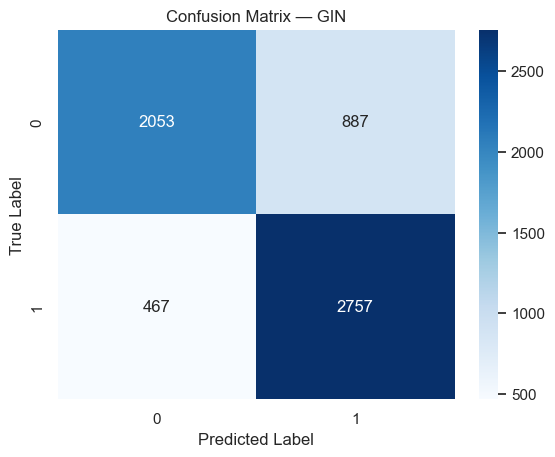

              precision    recall  f1-score   support

           0       0.81      0.70      0.75      2940
           1       0.76      0.86      0.80      3224

    accuracy                           0.78      6164
   macro avg       0.79      0.78      0.78      6164
weighted avg       0.78      0.78      0.78      6164



In [6]:
plot_confusion_matrix(gin_df, "GIN")

## Graph regularity effect

In [7]:
analyze_regularity(gin_df, "GIN")

--- GIN ---
Regular graphs in dataset:     20.33%
Regular graphs among errors:   20.09%


## Graph size effect

The plot below shows error rate aggregated by node count.

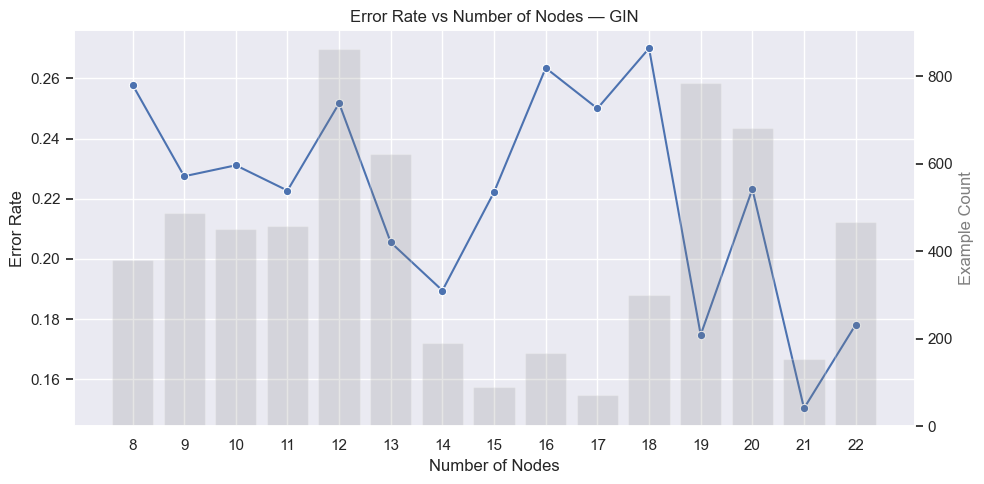

In [8]:
plot_error_by_size(gin_df, "GIN")

## Feature importance analysis

In [9]:
gin_importance = analyze_feature_importance(gin_df, "GIN")

--- GIN ---


,RF Importance,Permutation Importance,LR Coefficient,Spearman r,p-value
Feature,,,,,
aut_grp_size,0.5838,0.0274,-0.0001,-0.023,0.0697
paut_relative_size,0.2194,0.0109,1.7691,0.030,0.0201
num_nodes,0.1007,0.0090,0.0473,-0.043,0.0007
paut_size,0.0961,0.0077,-0.1112,-0.029,0.0222


### Interpretation

#### The RF vs permutation importance gap

`aut_grp_size` drops from 0.58 (RF importance) to 0.027 (permutation importance on the same model). This is a textbook example of RF's cardinality bias — it overrates high-cardinality continuous variables regardless of genuine predictive power. The permutation importance is the more trustworthy number here.

#### Logistic regression tells a different story

`paut_relative_size` has by far the largest coefficient (1.77), while `aut_grp_size` is nearly zero (−0.0001). This suggests that once the relative measure is accounted for, the absolute group size adds almost nothing. The relative measure subsumes the signal the absolute one appeared to have.

#### The Spearman correlations are humbling

All effect sizes are tiny (r < 0.05), and `aut_grp_size` doesn't reach significance at p=0.05. Individually, these structural features barely predict errors at all.

### Conclusion

The methods roughly converge on `paut_relative_size` as the most consistent predictor across logistic regression and permutation importance — but even that effect is small. The honest conclusion is:

> These four structural features do not strongly explain where the model fails. Errors are largely not predictable from node count, group size, or regularity alone.

This is not a failure of analysis — it is a real result. It means either the failure mode lies in feature interactions not captured here, or the hard cases are hard for reasons that summary statistics cannot encode. The latter interpretation is consistent with the WL expressiveness argument: the difficulty of a graph instance for a GIN is not reducible to a single structural number.

### Next steps

Inspect the `confident_wrong` cases directly at the graph level. The pattern that explains these failures may only be visible structurally, not statistically.

## Effect of relative partial automorphism size

Spearman r = 0.030, p = 0.0201


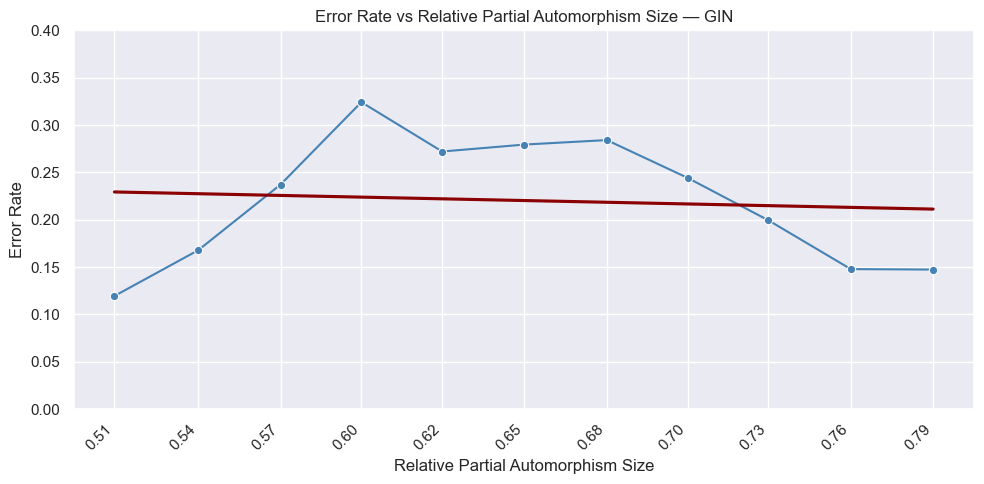

In [10]:
plot_error_by_paut_relative_size(gin_df, "GIN", ylim=(0, 0.4))

# GPS

## Confusion Matrix

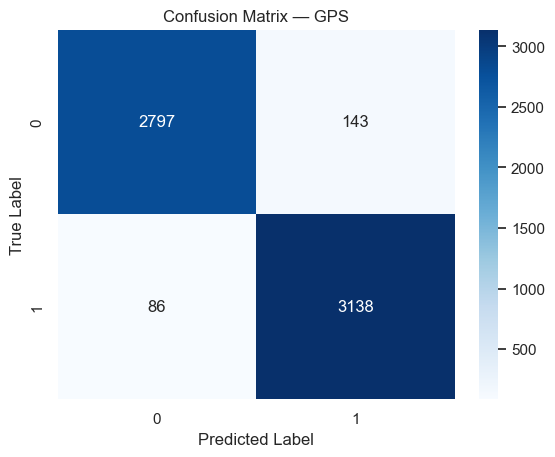

              precision    recall  f1-score   support

           0       0.97      0.95      0.96      2940
           1       0.96      0.97      0.96      3224

    accuracy                           0.96      6164
   macro avg       0.96      0.96      0.96      6164
weighted avg       0.96      0.96      0.96      6164



In [11]:
plot_confusion_matrix(gps_df, "GPS")

## Graph regularity effect

In [12]:
analyze_regularity(gps_df, "GPS")

--- GPS ---
Regular graphs in dataset:     20.33%
Regular graphs among errors:   44.10%


## Graph size effect

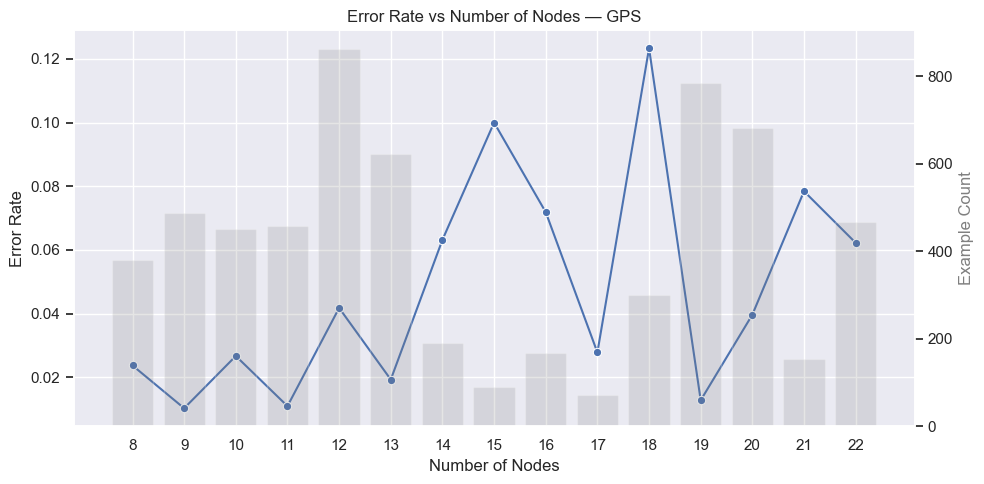

In [13]:
plot_error_by_size(gps_df, "GPS")

## Feature importance analysis

In [14]:
gps_importance = analyze_feature_importance(gps_df, "GPS")

--- GPS ---


,RF Importance,Permutation Importance,LR Coefficient,Spearman r,p-value
Feature,,,,,
aut_grp_size,0.5948,0.0051,-0.0000,0.032,0.0114
num_nodes,0.1264,0.0018,0.2599,0.062,0.0000
paut_relative_size,0.1672,0.0018,-0.2484,-0.086,0.0000
paut_size,0.1116,0.0015,-0.3293,0.025,0.0474


## Effect of relative partial automorphism size

Spearman r = -0.086, p = 0.0000


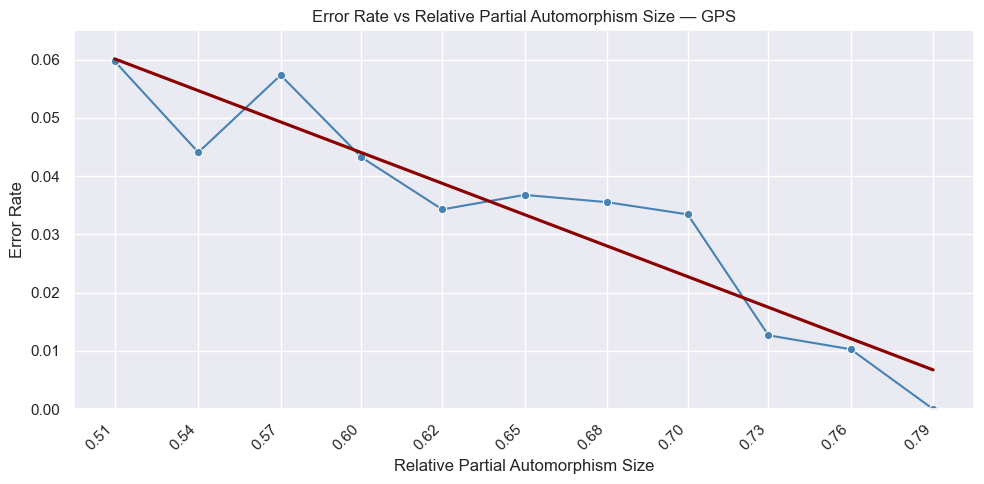

In [15]:
plot_error_by_paut_relative_size(gps_df, "GPS", ylim=(0, 0.065))

# GIN vs GPS: confident GIN failures corrected by GPS

Select graphs where GPS predicted correctly but GIN was both wrong and confident (predicted probability far from 0.5).

In [16]:
gin_comp = gin_df[["sample_idx", "true_label", "num_nodes", "prediction", "pred_prob", "correct"]].copy()
gps_comp = gps_df[["sample_idx", "prediction", "pred_prob", "correct"]].copy()

gin_comp = gin_comp.rename(columns={"prediction": "gin_pred", "pred_prob": "gin_prob", "correct": "gin_correct"})
gps_comp = gps_comp.rename(columns={"prediction": "gps_pred", "pred_prob": "gps_prob", "correct": "gps_correct"})

merged = gin_comp.merge(gps_comp, on="sample_idx")
merged["gin_confidence"] = (merged["gin_prob"] - 0.5).abs()

# Filter: GPS correct, GIN wrong and confident, graph size 8-10
candidates = merged[
    merged["gps_correct"] & ~merged["gin_correct"] &
    merged["num_nodes"].between(8, 10)
].copy()
candidates = candidates.sort_values("gin_confidence", ascending=False)

selected = candidates.head(5)
print(f"Found {len(candidates)} candidates (8-10 nodes); selecting top 5 by GIN confidence.")
print(selected[["sample_idx", "num_nodes", "true_label", "gin_pred", "gin_prob", "gin_confidence", "gps_pred", "gps_prob"]].to_string(index=False))

Found 303 candidates (8-10 nodes); selecting top 5 by GIN confidence.
 sample_idx  num_nodes  true_label  gin_pred  gin_prob  gin_confidence  gps_pred     gps_prob
        241          9           0         1  0.994826        0.494826         0 4.370792e-09
       3832          9           1         0  0.006468        0.493532         1 1.000000e+00
        243          9           0         1  0.992771        0.492771         0 4.946618e-07
       5068         10           0         1  0.991451        0.491451         0 8.917930e-09
       4838          8           0         1  0.986566        0.486566         0 1.153996e-01


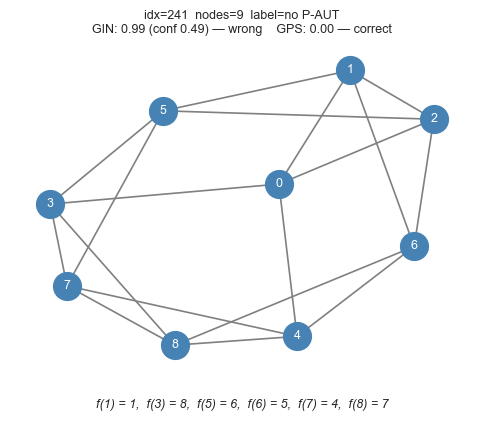

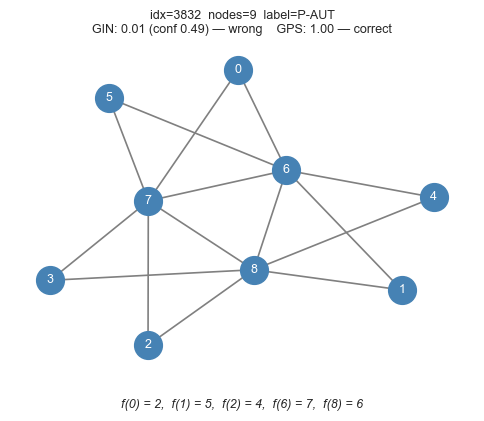

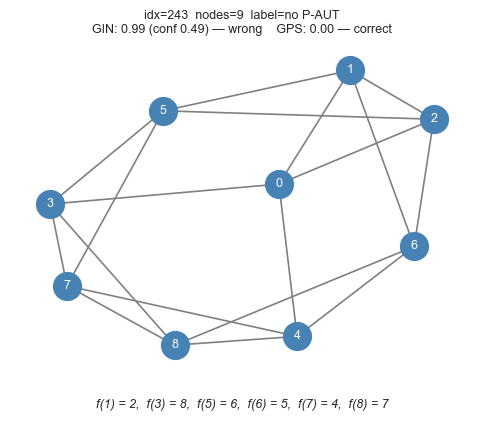

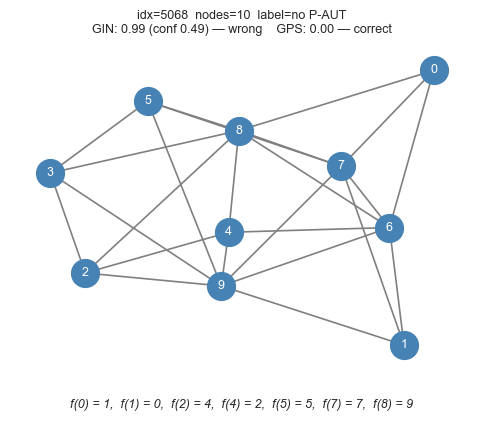

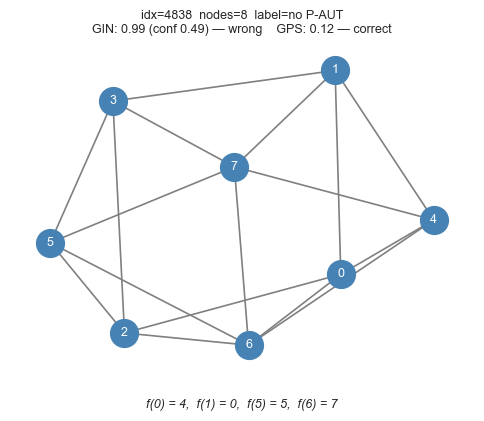

In [17]:
from utils import FEATURE_TARGET_ID

raw_test = gin_results["dataset"]

def decode_mapping(graph):
    """Recover the partial automorphism mapping from node features."""
    x = graph.x
    n = graph.num_nodes
    mapping = {}
    for node in range(n):
        encoded = x[node, FEATURE_TARGET_ID].item()
        if encoded != -1:
            target = round(encoded * n)
            mapping[node] = target
    return mapping

for _, row in selected.iterrows():
    idx = int(row["sample_idx"])
    graph = raw_test[idx]

    G = torch_geometric.utils.to_networkx(graph, to_undirected=True)
    mapping = decode_mapping(graph)

    mapping_str = ",  ".join(f"f({s}) = {t}" for s, t in sorted(mapping.items()))

    pos = nx.spring_layout(G, seed=42)

    fig, ax = plt.subplots(figsize=(5, 4))
    nx.draw(
        G, pos, ax=ax,
        node_color="steelblue",
        node_size=400,
        with_labels=True,
        font_size=9,
        font_color="white",
        edge_color="gray",
        width=1.2,
    )

    true_lbl = int(row["true_label"])
    ax.set_title(
        f"idx={idx}  nodes={int(row['num_nodes'])}  label={'P-AUT' if true_lbl == 1 else 'no P-AUT'}\n"
        f"GIN: {row['gin_prob']:.2f} (conf {row['gin_confidence']:.2f}) — wrong    GPS: {row['gps_prob']:.2f} — correct",
        fontsize=9,
    )
    fig.text(0.5, -0.04, mapping_str, ha="center", fontsize=9, style="italic")

    plt.tight_layout()
    plt.show()